In [1]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.signal import find_peaks
import pandas as pd
import time
from tqdm import tqdm
from matplotlib.patches import Rectangle

total_start = time.time()

sys.path.append(r'C:\Program Files\ANSYS Inc\v251\Lumerical\api\python') # QP5 Lumerical API path
# sys.path.append(r'C:\Program Files\Lumerical\v251\api\python')  #QP3 Lumerical API path
# sys.path.append(r'C:\Program Files\Lumerical\v251\api\python')  #QP2 Lumerical API path

WORKDIR = Path().resolve()                  # auto: wherever the notebook lives
REPO_ROOT = WORKDIR.parents[1]             # still assumes scripts/MODE_bend_wg/ structure
os.chdir(WORKDIR)
print("Current working directory:", os.getcwd())

data_save_dir = WORKDIR / "results" / "Data_Mode_Calculations"
data_save_dir.mkdir(parents=True, exist_ok=True)

print("Working dir:", WORKDIR)
print("Data saved to:", data_save_dir)


Current working directory: D:\Ligentic_NU_1_TapeOut_April2026\scripts\MODE_bend_wg
Working dir: D:\Ligentic_NU_1_TapeOut_April2026\scripts\MODE_bend_wg
Data saved to: D:\Ligentic_NU_1_TapeOut_April2026\scripts\MODE_bend_wg\results\Data_Mode_Calculations


In [2]:
import lumapi as lm
# Ensure Lumerical MODE session starts correctly
try:
    f.redraw()  # Test if 'f' is already active
except NameError:
    print("Starting new Lumerical MODE session...")
    f = lm.MODE()  
except AttributeError:
    print("Reinitializing Lumerical MODE session...")
    f = lm.MODE()  

# Check if f is valid
if f is None:
    raise RuntimeError("Failed to initialize Lumerical MODE session. Check your Lumerical")
                
LumFileName = 'Ring_MODE_width_Sweep_neff.lms' # save .lms file
f.save(LumFileName)
# Clear existing elements
f.switchtolayout()
f.selectall()
f.delete()


Starting new Lumerical MODE session...


C:\Program Files\ANSYS Inc\v251\Lumerical\api\python\lumapi.py:895: SyntaxWarning: invalid escape sequence '\s'
  message = re.sub('^(Error:)\s(prompt line)\s[0-9]+:', '', str(rvals[2])).strip()


In [3]:
#------------------------------------------------------------
# PARAMETERS
#------------------------------------------------------------
results = []

Lambda0        = 1550E-9
Width          = 1500E-9
Height         = 800E-9
Radius         = 100E-6

Material       = "Si3N4 (Silicon Nitride) - Luke"
BackgroundMaterial = "SiO2 (Glass) - Palik"


In [4]:
#---------------------------------------------------------------
# Bend WG setup
#---------------------------------------------------------------

f.addrect()
f.set('x',0)
f.set('y',0)
f.set('x span', 0.25*Radius)
f.set('y span', Width)
f.set('z',0)
f.set('z span',Height)
f.set ('material', Material)

#---------------------------------------------------------------
# Mode solver 
#---------------------------------------------------------------

f.addfde()
f.set("solver type", "2D X Normal")
f.set("x",0)  # Aligned with the right ring
f.set("y", 0)  # Centered in Y
f.set("y span", 2 * Width)
f.set("z", 0)  # Centered in Z
f.set("z span", 2 * Width)
f.set("wavelength", Lambda0)
f.set("background material", BackgroundMaterial)
f.set("bent waveguide", 1)
f.set("bend radius", Radius)
f.set("bend orientation", 0)

#---------------------------------------------------------------
# Run
#---------------------------------------------------------------
f.findmodes()


20.0

In [5]:

#---------------------------------------------------------------
# Results and plots
#---------------------------------------------------------------

# Extract scalars
neff = f.getdata("FDE::data::mode1", "neff").flat[0]
ng = f.getdata("FDE::data::mode1", "ng").flat[0]
loss = f.getdata("FDE::data::mode1", "loss")
te_frac = f.getdata("FDE::data::mode1", "TE polarization fraction")
aeff = f.getdata("FDE::data::mode1", "mode effective area")

# Extract fields
Ex = np.squeeze(f.getdata("FDE::data::mode1", "Ex"))
Ey = np.squeeze(f.getdata("FDE::data::mode1", "Ey"))
Ez = np.squeeze(f.getdata("FDE::data::mode1", "Ez"))

results.append({
    'width_nm': Width * 1e9,
    'radius_um': Radius * 1e6,
    'neff': np.real(neff),
    'ng': np.real(ng),
    'loss_dB_cm': np.real(loss) / 100,
    'te_frac': np.real(te_frac),
    'aeff_um2': np.real(aeff) * 1e12,
    'Ex': Ex,
    'Ey': Ey,
    'Ez': Ez
})

print(f"  neff={np.real(neff):.4f}, ng={np.real(ng):.3f}, loss={np.real(loss)/100:.3f} dB/cm")

  neff=1.8288, ng=2.124, loss=0.000 dB/cm


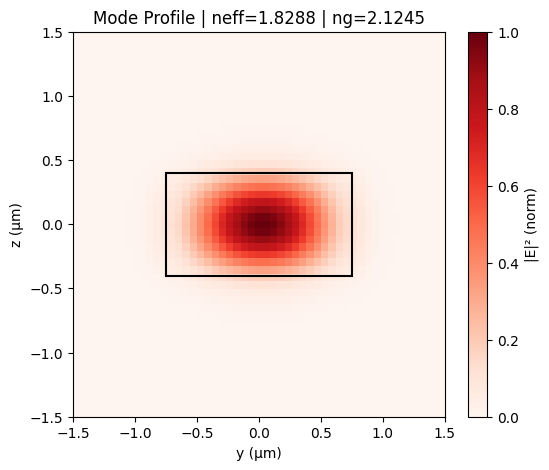

In [6]:
E_total = np.abs(Ex)**2 + np.abs(Ey)**2 + np.abs(Ez)**2
E_norm  = E_total / E_total.max()

y_span = 2*Width*1E6
z_span = y_span

plt.figure(figsize=(6,5))
extent = [-y_span/2, y_span/2, -z_span/2, z_span/2]

plt.imshow(
    E_norm.T,
    origin='lower',
    cmap='Reds',
    aspect='auto',
    extent=extent
)

# ---- STRUCTURE OUTLINE (NEW) ----
rect = Rectangle(
    (-Width*1e6/2, -Height*1e6/2),   # lower-left corner
    Width*1e6,                       # width along y
    Height*1e6,                      # height along z
    linewidth=1.5,
    edgecolor='black',
    facecolor='none'
)
plt.gca().add_patch(rect)
# --------------------------------

plt.colorbar(label='|E|² (norm)')
plt.xlabel('y (µm)')
plt.ylabel('z (µm)')
plt.title(f'Mode Profile | neff={np.real(neff):.4f} | ng={np.real(ng):.4f}')
plt.gcf().set_dpi(100)
plt.show()


In [7]:
WidthVec  = np.array([700,800,900,1000,1100,1200,1300,1400,1500,1600,1700,1800,1900,2000, 2500, 3000, 3500, 4000]) * 1e-9
RadiusVec = np.array([5,10,15,20,25,30,35,40,45,50,60,70,80,90,100,110,120]) * 1e-6

results = []

for Radius in tqdm(RadiusVec, desc="Radius sweep"):
    for Width in tqdm(WidthVec, desc="Width sweep", leave=False):

        f.switchtolayout()
        f.select("rectangle")
        f.set('y span', Width)

        f.select("FDE")
        f.set("y span", 2 * Width)
        f.set("z span", max(2 * Width, 6 * Height))
        f.set("bend radius", Radius)
        f.set("wavelength", 1550e-9)
        f.findmodes()

        neff = np.real(f.getdata("FDE::data::mode1", "neff").flat[0])
        ng   = np.real(f.getdata("FDE::data::mode1", "ng").flat[0])

        results.append({
            'width_nm':  Width  * 1e9,
            'radius_um': Radius * 1e6,
            'neff':      neff,
            'ng':        ng
        })
        # print(f"R={Radius*1e6:.0f}um W={Width*1e9:.0f}nm | neff={neff:.4f} ng={ng:.4f}")

df = pd.DataFrame(results)
df.to_csv(os.path.join(data_save_dir, 'neff_ng_sweep.csv'), index=False)
print(df)

Radius sweep: 100%|██████████| 17/17 [04:56<00:00, 17.47s/it]

     width_nm  radius_um      neff        ng
0       700.0        5.0  1.726965  2.072484
1       800.0        5.0  1.755299  2.104454
2       900.0        5.0  1.780254  2.126298
3      1000.0        5.0  1.802478  2.143438
4      1100.0        5.0  1.822752  2.159346
..        ...        ...       ...       ...
301    2000.0      120.0  1.849519  2.107494
302    2500.0      120.0  1.860791  2.100132
303    3000.0      120.0  1.869366  2.097707
304    3500.0      120.0  1.872871  2.097780
305    4000.0      120.0  1.886096  2.108412

[306 rows x 4 columns]
